<a href="https://colab.research.google.com/github/uvidhi/Credit-Card-KMeans-Clustering/blob/main/Untitled16_ipynbCredit_Card_KMeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving CC GENERAL.csv to CC GENERAL.csv
Shape of Dataset:
(8950, 18)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 no

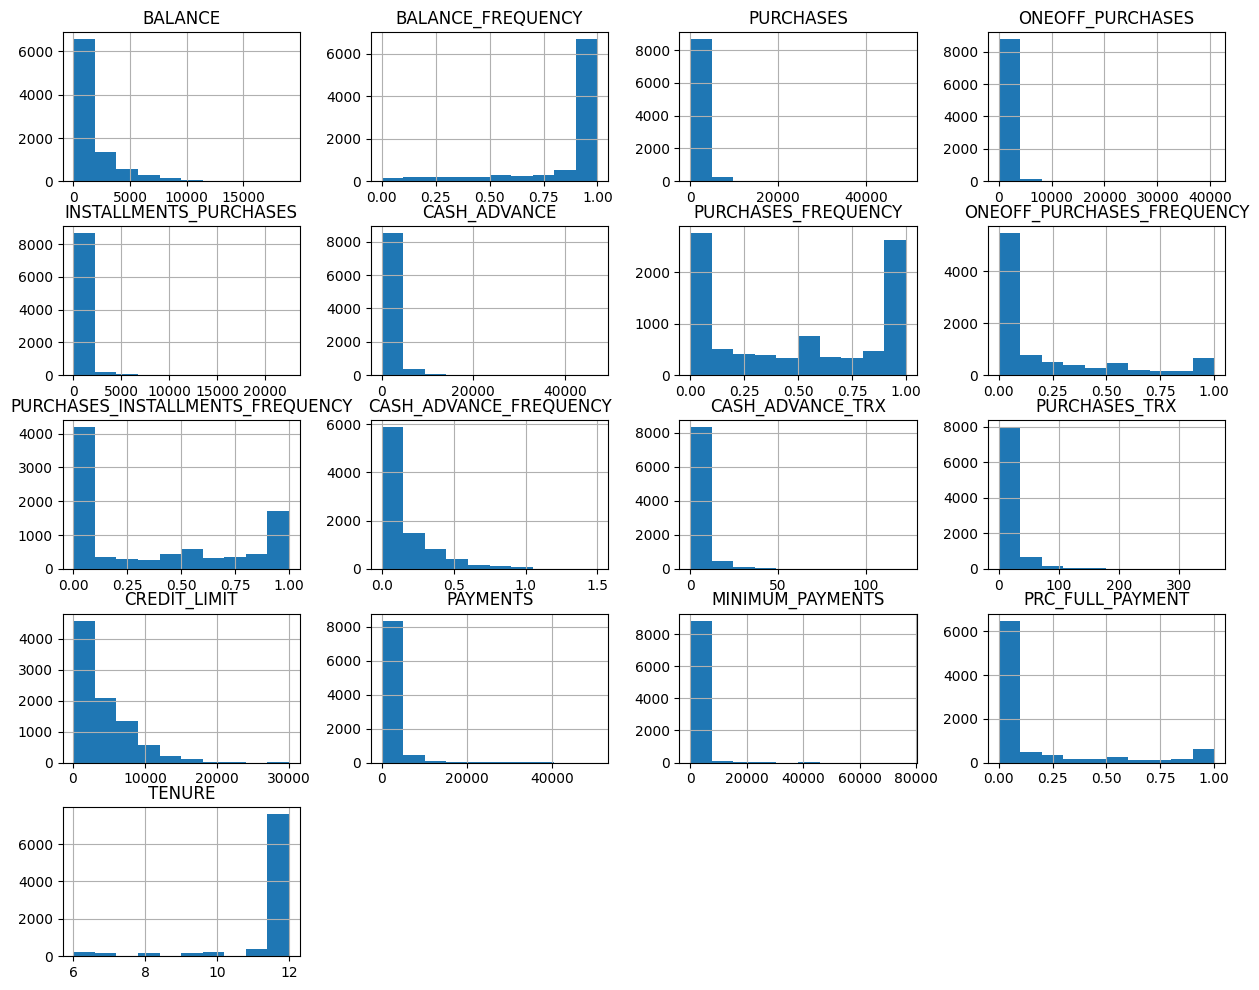

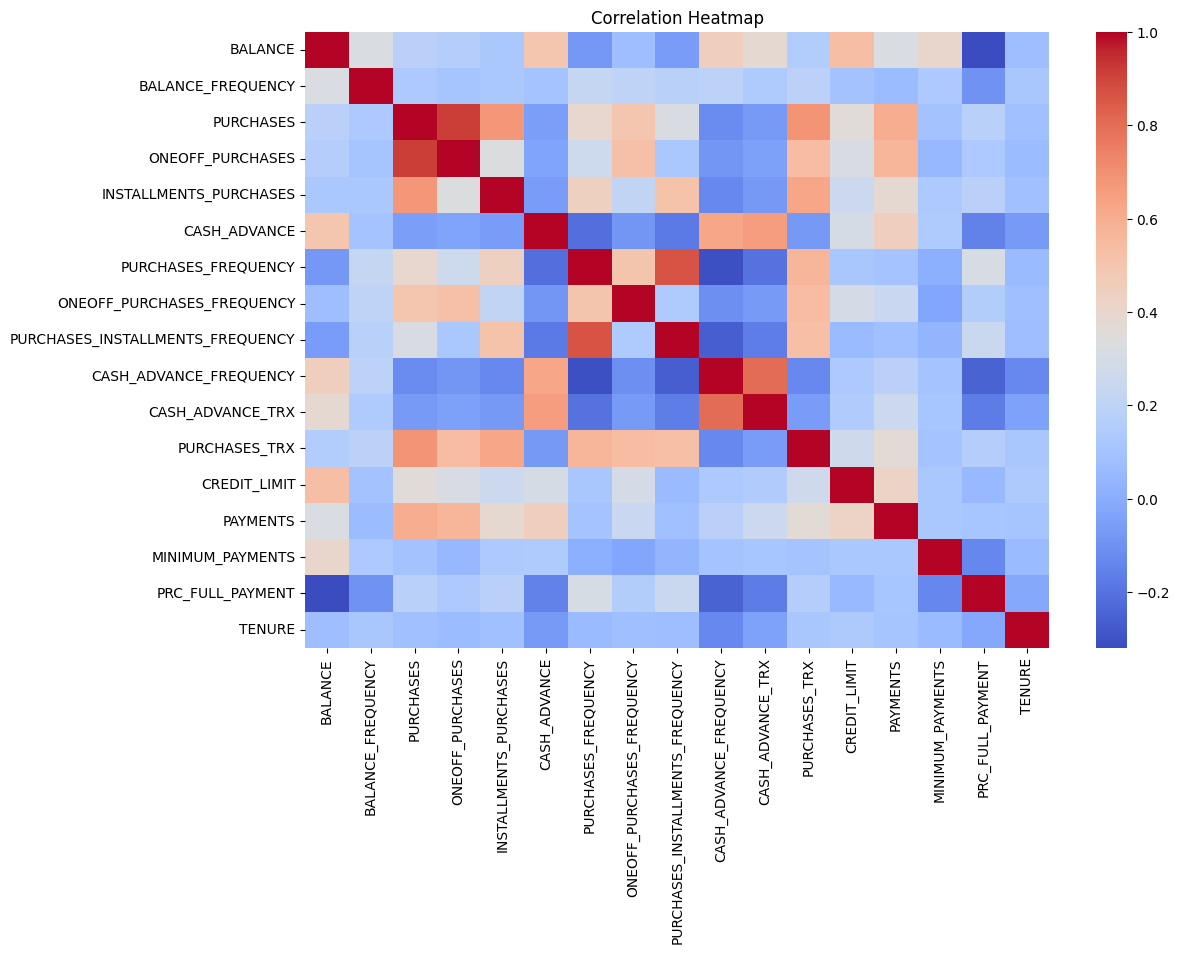

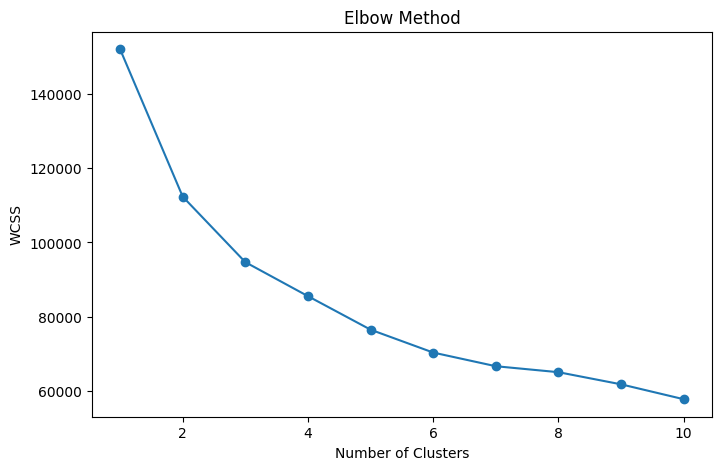


Silhouette Score: 0.2290620030765282


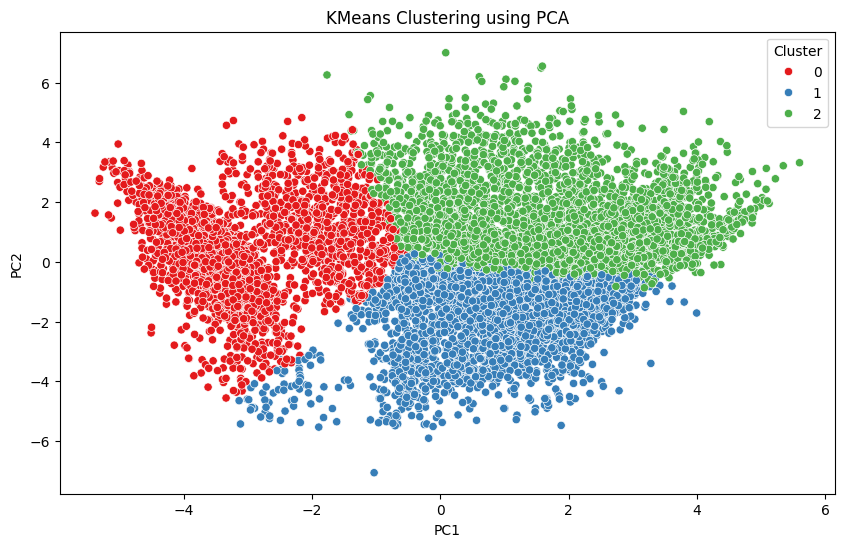


Cluster Summary:
             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        2331.548971           0.915416    90.647595         75.907226   
1         229.184339           0.724781   472.137741        165.022069   
2        2083.757277           0.980252  2285.183845       1431.733115   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                     14.783150   2123.702880             0.063905   
1                    307.509116     29.483141             0.538406   
2                    853.894668    818.632646             0.823930   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
0                          0.040070                          0.021799   
1                          0.078555      

In [2]:

# IMPORT LIBRARIES


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# LOAD DATASET


from google.colab import files

uploaded = files.upload()

df = pd.read_csv("CC GENERAL.csv")

# =========================
# DATASET SUMMARY
# =========================

print("Shape of Dataset:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nFirst 5 Rows:")
print(df.head())

# =========================
# HANDLE MISSING VALUES
# =========================

print("\nMissing Values:")
print(df.isnull().sum())

# Remove customer ID column
df.drop("CUST_ID", axis=1, inplace=True)

# Fill missing values using median
imputer = SimpleImputer(strategy='median')

df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

# =========================
# DESCRIPTIVE STATISTICS
# =========================

print("\nDescriptive Statistics:")
print(df_imputed.describe())

print("\nSkewness:")
print(df_imputed.skew())

print("\nKurtosis:")
print(df_imputed.kurt())

# =========================
# DATA TRANSFORMATION
# =========================

# Log transformation for skewed data
df_log = np.log1p(df_imputed)

# =========================
# FEATURE SCALING
# =========================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_log)

# =========================
# EDA VISUALIZATION
# =========================

# Histogram
df_imputed.hist(figsize=(15, 12))
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(df_imputed.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# =========================
# ELBOW METHOD
# =========================

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

# =========================
# TRAIN KMEANS MODEL
# =========================

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels
df_imputed["Cluster"] = clusters

# =========================
# SILHOUETTE SCORE
# =========================

score = silhouette_score(scaled_data, clusters)

print("\nSilhouette Score:", score)

# =========================
# PCA FOR VISUALIZATION
# =========================

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

# Create PCA dataframe
pca_df = pd.DataFrame(data=pca_data, columns=["PC1", "PC2"])

pca_df["Cluster"] = clusters

# =========================
# VISUALIZE CLUSTERS
# =========================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette="Set1"
)

plt.title("KMeans Clustering using PCA")

plt.show()

# =========================
# CLUSTER INTERPRETATION
# =========================

cluster_summary = df_imputed.groupby("Cluster").mean()

print("\nCluster Summary:")
print(cluster_summary)